# Hands-on: Comparação de Variantes do SARS-CoV-2 
---

## Contexto biológico

Em 2021, surgiram várias variantes do SARS-CoV-2 com mutações que alteraram a transmissibilidade e a capacidade de escape imune do vírus. Uma das mais estudadas foi a variante **Delta (B.1.617.2)**, identificada pela primeira vez na Índia.

Neste trabalho compararás dois genomas completos:

| Ficheiro | Accession | Descrição |
|---|---|---|
| `SARS-CoV-2_ref_aln.fasta` | NC_045512.2 | Wuhan-Hu-1 (estirpe de referência, 2019) |
| `SARS-CoV-2_var_aln.fasta` | MZ359844.1  | Variante indiana, 2021 |

> **Nota:** Os dois ficheiros já estão **pré-alinhados** . Os `-` representam gaps.

---

## Como funciona este notebook

Este é um exercício de **montagem de puzzle**.

Tens disponíveis todas as funções necessárias — já implementadas e prontas a usar. O teu trabalho é **perceber o que cada função faz** e **ligá-las na ordem certa** para construir o workflow de análise.

```
FASTA alinhados
      ↓
 Passo 1 — Ler as sequências         →  read_fasta(...)
      ↓
 Passo 2 — Explorar o alinhamento    →  explore_alignment(...)
      ↓
 Passo 3 — Divergência por janelas   →  compare_distances_windowed(...)
      ↓
 Passo 4 — Visualizar                →  matplotlib (codigo dado - corre e analisa)
      ↓
 Passo 5 — Gráfico completo          →  (código dado — corre e analisa)
      ↓
 Passo 6 — Interpretação biológica
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

---
## Peças do Puzzle — Funções Disponíveis

As células abaixo definem todas as funções que vais precisar. **Lê cada uma com atenção** — precisas de perceber o que recebem, o que devolvem, e quando as usar — mas não precisas de as alterar.

| Função | O que faz | Recebe | Devolve |
|---|---|---|---|
| `read_fasta(path)` | Lê um ficheiro FASTA | caminho do ficheiro | `(header, sequência)` |
| `explore_alignment(seq1, seq2)` | Conta matches, mismatches, gaps | 2 sequências alinhadas | dicionário com estatísticas |
| `hamming_distance(s1, s2)` | Distância de Hamming | 2 strings de igual comprimento | `int` |
| `edit_distance(s1, s2)` | Edit Distance (Levenshtein) | 2 strings (qualquer comprimento) | `int` |
| `compare_distances_windowed(ref, var, window)` | Divergência por janelas — calcula **Hamming e Edit** | 2 sequências alinhadas + tamanho de janela | dicionário `{positions, hamming, edit}` |

In [2]:
def read_fasta(path):
    seq, header = [], ""
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                header = line[1:]
            else:
                seq.append(line.upper())
    return header, "".join(seq)

In [3]:
REF_PATH = #caminho para o arquivo da referência
VAR_PATH = #caminho para o arquivo da variante

hdr_ref, seq_ref = read_fasta(REF_PATH)
hdr_var, seq_var = read_fasta(VAR_PATH)

# Validação — não alteres esta parte
print(f"Referência : {hdr_ref[:70]}")
print(f"Comprimento: {len(seq_ref):,} colunas")
print()
print(f"Variante   : {hdr_var[:70]}")
print(f"Comprimento: {len(seq_var):,} colunas")
print()
assert len(seq_ref) == len(seq_var), "ERRO: comprimentos diferentes!"
print("✓ Comprimentos iguais — alinhamento carregado corretamente.")


SyntaxError: invalid syntax (1683580080.py, line 1)

### `explore_alignment` — Estatísticas globais do alinhamento

Dado um alinhamento de duas sequências, cada coluna pode ser:

| Tipo | Exemplo | Significado |
|---|---|---|
| **Match** | `A` / `A` | Base conservada |
| **Mismatch** | `A` / `T` | Substituição (SNP) |
| **Gap** | `A` / `-` | Inserção ou deleção (indel) |

In [ ]:
#completa o codigo para explorar o alinhamento, contando matches, mismatches e gaps.

def explore_alignment(seq1, seq2):
    """Conta matches, mismatches e gaps entre duas sequências alinhadas."""
    matches, mismatches, gaps = 0, 0, 0

    for r, v in zip(seq1, seq2):
        if r == '-' or v == '-':
            #gaps
        elif r == v:
            #matches
            matches += 1
        else:
            #mismatches
            mismatches += 1

    total = len(seq1)
    identity_pct = matches / total * 100

    return {
        "matches":      matches,
        "mismatches":   mismatches,
        "gaps":         gaps,
        "identity_pct": identity_pct,
    }

In [ ]:
# ── Passo 2: Explora o alinhamento ────────────────────────────────────────────
stats = explore_alignment(seq_ref, seq_var)

# Validação — não alteres esta parte
print("=== Estatísticas globais do alinhamento ===")
print(f"  Comprimento total : {len(seq_ref):,} colunas")
print(f"  Matches           : {stats['matches']:,}")
print(f"  Mismatches (SNPs) : {stats['mismatches']:,}")
print(f"  Gaps (indels)     : {stats['gaps']:,}")
print(f"  Identidade global : {stats['identity_pct']:.2f} %")
print()
print("Preview do alinhamento (posições 100–180):")
ref_preview = seq_ref[100:180]
var_preview = seq_var[100:180]
bar = "".join("|" if r == v and r != '-' else " " for r, v in zip(ref_preview, var_preview))
print(f"  REF: {ref_preview}")
print(f"       {bar}")
print(f"  VAR: {var_preview}")


=== Estatísticas globais do alinhamento ===
  Comprimento total : 29,903 colunas
  Matches           : 29,750
  Mismatches (SNPs) : 39
  Gaps (indels)     : 114
  Identidade global : 99.49 %

Preview do alinhamento (posições 100–180):
  REF: GGCTGCATGCTTAGTGCACTCACGCAGTATAATTAATAACTAATTACTGTCGTTGACAGGACACGAGTAACTCGTCTATC
       ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
  VAR: GGCTGCATGCTTAGTGCACTCACGCAGTATAATTAATAACTAATTACTGTCGTTGACAGGACACGAGTAACTCGTCTATC


### `hamming_distance` e `edit_distance` — Métricas de divergência

| Métrica | Aplica-se a | O que conta |
|---|---|---|
| **Hamming** | Strings de **igual comprimento** | Posições onde os caracteres diferem (gaps contam como mismatch) |
| **Edit Distance** | Qualquer comprimento | N.º mínimo de inserções, deleções e substituições — aplica-se **sem gaps** |

> **Porquê as duas?** O Hamming é O(n) e muito rápido; a Edit Distance é O(n²) mas mede o custo real de edição ignorando a penalização artificial dos gaps do alinhamento.

In [ ]:
def hamming_distance(s1, s2):
    """
    Distância de Hamming entre duas strings de IGUAL comprimento.
    Conta o número de posições onde os caracteres diferem.

    Parâmetros
    ----------
    s1, s2 : str  (devem ter o mesmo comprimento)

    Devolve
    -------
    int : número de posições divergentes

    Exemplos
    --------
    hamming_distance("ACGT", "ACTT")  →  1   (diferem na posição 2)
    hamming_distance("AC-T", "ACTT")  →  1   (gap conta como mismatch)
    """
    return sum(el1 != el2 for el1, el2 in zip(s1, s2))
    ...

In [ ]:
def edit_distance(s1, s2):
    """
    Edit Distance (Levenshtein) entre duas strings.
    Usa programação dinâmica com custo unitário para inserção, deleção e substituição.

    Parâmetros
    ----------
    s1, s2 : str  (podem ter comprimentos diferentes)

    Devolve
    -------
    int : número mínimo de operações de edição

    Nota: aplica-se às sequências SEM gaps (remove '-' antes de chamar esta função)
    """
    m, n = len(s1), len(s2)
    dp = np.zeros((m + 1, n + 1), dtype=int)

    for i in range(m + 1): dp[i][0] = i
    for j in range(n + 1): dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j],      # Delecção
                                   dp[i][j-1],      # Inserção
                                   dp[i-1][j-1])    # Substituição
    return dp[m][n]

### `compare_distances_windowed` — Divergência por janelas deslizantes

Percorre o alinhamento em blocos de `window` colunas e calcula, em cada bloco, **Hamming e Edit Distance** em simultâneo. Devolve um dicionário com três listas paralelas.

```
Alinhamento (~30 000 colunas)
│◄── janela 1 (1 000) ──►│◄── janela 2 ──►│ ...
       ↓ hamming + edit       ↓ hamming + edit
```

---
## Monta o Workflow

As funções estão definidas. Agora é a tua vez: **chama-as na ordem certa, com os argumentos certos.**


In [ ]:
#O pseudocódigo esta nos slides da apresentação. Completa as partes faltantes.

def compare_distances_windowed(seq_ref_aln, seq_var_aln, window=1000):
    """
    Calcula Hamming Distance e Edit Distance em janelas não sobrepostas.

    Parâmetros
    ----------
    seq_ref_aln, seq_var_aln : str
        Sequências alinhadas (mesmo comprimento, com '-' nos gaps).
    window : int
        Tamanho da janela em colunas de alinhamento (default: 1 000).

    Devolve
    -------
    dict com três listas paralelas:
        "positions" : posição central de cada janela em coordenadas da referência
        "hamming"   : Hamming Distance por janela (sequências alinhadas, com gaps)
        "edit"      : Edit Distance por janela (sequências sem gaps)
    """
    aln_len = len(seq_ref_aln)

    ref_coord = 0
    ref_pos_map = []
    for c in seq_ref_aln:
        ref_pos_map.append(ref_coord)
        if c != '-':
            ref_coord += 1

    results = {"positions": [], "hamming": [], "edit": []}

    for start in range(0, aln_len - window + 1, window):
        end = start + window

        chunk_ref_aln = #completa aqui
        chunk_var_aln = #completa aqui

        #Na edit queremos ignorar as gaps, por isso precisamos de substituir '-'.
        chunk_ref_raw = chunk_ref_aln.replace()
        chunk_var_raw = chunk_var_aln.replace()

        results["positions"].append(ref_pos_map[start + window // 2])
        results["hamming"].append("------------------------------------") # completa aqui
        results["edit"].append("-----------------------") # completa aqui

    return results

In [ ]:
# ── Passo 3: Divergência por janelas ─────────────────────────────────────────
# Atenção: o cálculo da Edit Distance demora 1-2 minutos (é O(n²) por janela).
WINDOW = 1000

results = compare_distances_windowed() # completa aqui

# Extrai os dados do dicionário de resultados
positions_ref    = results["positions"]
dist_hamming     = results["hamming"]
dist_edit        = results["edit"]

# Calcula divergência por bp (para os gráficos)
div_per_bp_hamming = [d / WINDOW for d in dist_hamming]
div_per_bp_edit    = [d / WINDOW for d in dist_edit]

# Calcula acumuladas
cumulative_hamming = list(np.cumsum(div_per_bp_hamming))
cumulative_edit    = list(np.cumsum(div_per_bp_edit))

# Validação — não alterar
print(f"Janelas analisadas         : {len(positions_ref)}")
print(f"Divergência total (Hamming): {sum(dist_hamming):,} colunas")
print(f"Divergência total (Edit)   : {sum(dist_edit):,} edições")
print()
print("Top 5 janelas mais divergentes (Hamming):")
ranked = sorted(zip(div_per_bp_hamming, div_per_bp_edit, positions_ref), reverse=True)
for dpb_h, dpb_e, pos in ranked[:5]:
    print(f"  ~{pos:>6,} nt  →  Hamming: {dpb_h:.4f} | Edit: {dpb_e:.4f}")


Janelas analisadas         : 29
Divergência total (Hamming): 99 colunas
Divergência total (Edit)   : 99 edições

Top 5 janelas mais divergentes (Hamming):
  ~   500 nt  →  Hamming: 0.0520 | Edit: 0.0520
  ~28,500 nt  →  Hamming: 0.0110 | Edit: 0.0110
  ~22,500 nt  →  Hamming: 0.0080 | Edit: 0.0080
  ~27,500 nt  →  Hamming: 0.0030 | Edit: 0.0030
  ~23,500 nt  →  Hamming: 0.0020 | Edit: 0.0020


---
### Passo 4 — Visualização (codigo dado)

Vai gerar o gráfico das distancias por window

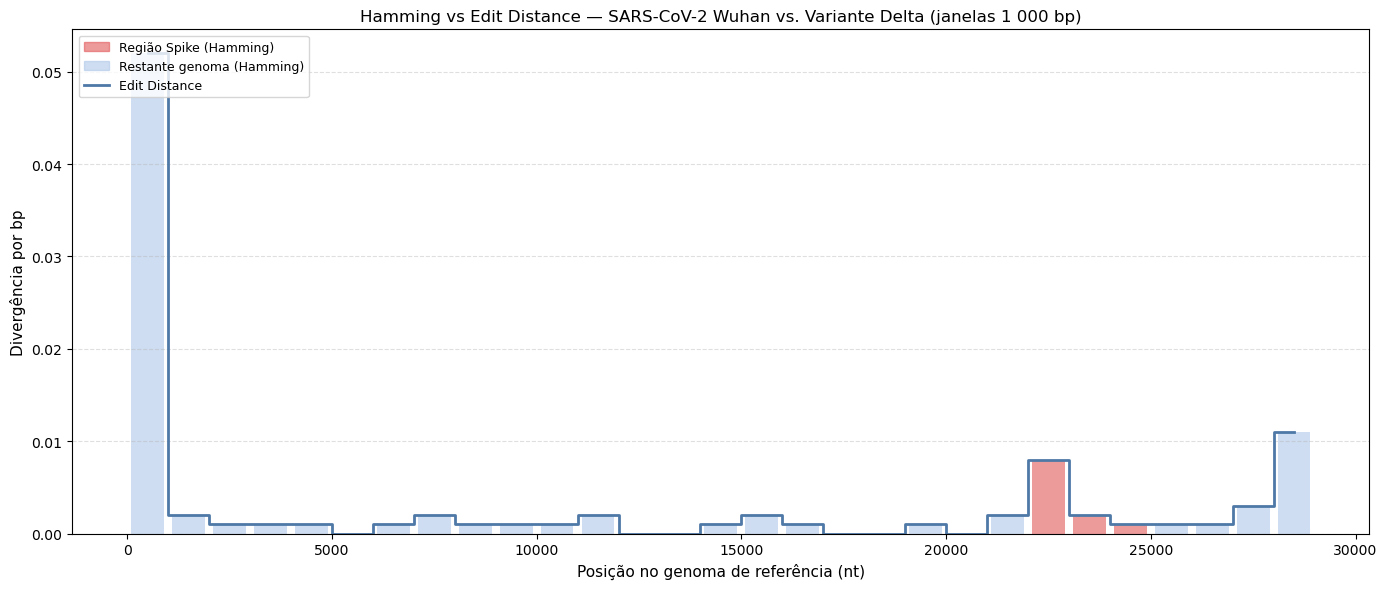

In [ ]:
SPIKE_START, SPIKE_END = 21_563, 25_384

fig, ax = plt.subplots(figsize=(14, 6))

# Tarefa B: lista de cores — #e15759 para Spike, #aec7e8 para o resto
colors = ["#e15759" if SPIKE_START <= p <= SPIKE_END else "#aec7e8"
          for p in positions_ref]

# Tarefa A: barras de Hamming Distance
ax.bar(positions_ref, div_per_bp_hamming, width=WINDOW * 0.8,
       color=colors, alpha=0.6, label="Hamming Distance", align="center")

# Tarefa A: linha de Edit Distance por cima das barras
ax.step(positions_ref, div_per_bp_edit, where='mid', color="#4e79a7",
        linewidth=2, label="Edit Distance (Levenshtein)")

ax.set_xlabel("Posição no genoma de referência (nt)", fontsize=11)
ax.set_ylabel("Divergência por bp", fontsize=11)
ax.set_title("Hamming vs Edit Distance — SARS-CoV-2 Wuhan vs. Variante Delta (janelas 1 000 bp)")
ax.grid(axis="y", linestyle="--", alpha=0.4)

legend_elements = [
    mpatches.Patch(color="#e15759", alpha=0.6, label="Região Spike (Hamming)"),
    mpatches.Patch(color="#aec7e8", alpha=0.6, label="Restante genoma (Hamming)"),
    plt.Line2D([0], [0], color="#4e79a7", lw=2, label="Edit Distance"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="upper left")

plt.tight_layout()
plt.show()


---
### Passo 5 — Gráfico comparativo completo *(código dado)*

O código abaixo gera um gráfico com 3 painéis:
1. **Divergência cumulativa** das duas métricas ao longo do genoma
2. **Divergência por janela** com os subdomínios da Spike destacados
3. **Mapa de genes** do SARS-CoV-2

Corre a célula e observa o resultado. As perguntas do Passo 6 baseiam-se nele.

> **Nota:** Só funciona depois de concluíres o Passo 3 (as variáveis `positions_ref`, `div_per_bp_hamming`, etc. têm de estar definidas).

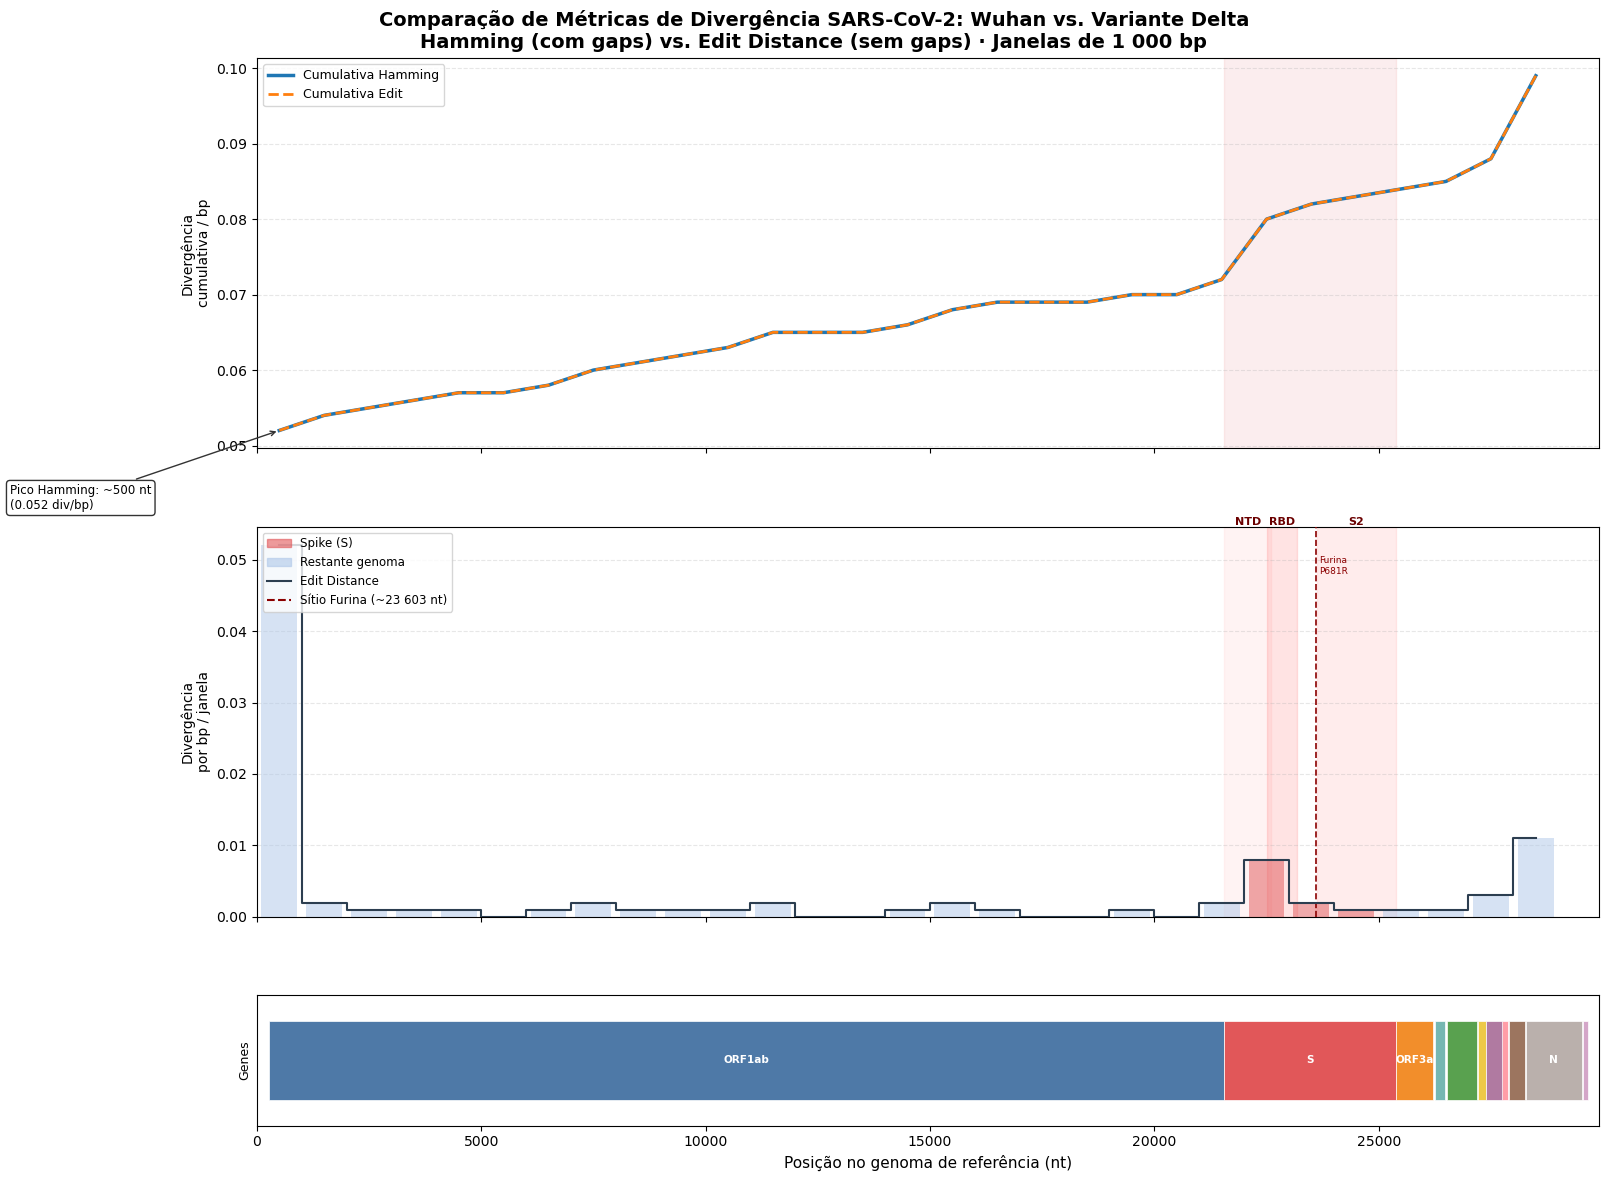

In [ ]:
GENES = [
    ("ORF1ab", 266,   21555, "#4e79a7"),
    ("S",      21563, 25384, "#e15759"),
    ("ORF3a",  25393, 26220, "#f28e2b"),
    ("E",      26245, 26472, "#76b7b2"),
    ("M",      26523, 27191, "#59a14f"),
    ("ORF6",   27202, 27387, "#edc948"),
    ("ORF7a",  27394, 27759, "#b07aa1"),
    ("ORF7b",  27756, 27887, "#ff9da7"),
    ("ORF8",   27894, 28259, "#9c755f"),
    ("N",      28274, 29533, "#bab0ac"),
    ("ORF10",  29558, 29674, "#d4a6c8"),
]
SPIKE_DOMAINS = [
    ("NTD", 21563, 22599, "#ffb3b3"),
    ("RBD", 22517, 23183, "#ff4444"),
    ("S2",  23623, 25384, "#ff8080"),
]
FURINA_POS = 23603

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(16, 12), sharex=True,
    gridspec_kw={"height_ratios": [1.8, 1.8, 0.6]}
)
fig.suptitle(
    "Comparação de Métricas de Divergência SARS-CoV-2: Wuhan vs. Variante Delta\n"
    "Hamming (com gaps) vs. Edit Distance (sem gaps) · Janelas de 1 000 bp",
    fontsize=14, fontweight="bold"
)

x = positions_ref

# --- Painel 1: Divergência Cumulativa ---
ax1.plot(x, cumulative_hamming, color="#1f77b4", linewidth=2.5, label="Cumulativa Hamming")
ax1.plot(x, cumulative_edit,    color="#ff7f0e", linewidth=2, linestyle="--", label="Cumulativa Edit")
ax1.axvspan(21563, 25384, alpha=0.1, color="#e15759", zorder=0)
ax1.set_ylabel("Divergência\ncumulativa / bp", fontsize=10)
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

max_idx = int(np.argmax(div_per_bp_hamming))
ax1.annotate(
    f"Pico Hamming: ~{x[max_idx]:,} nt\n({div_per_bp_hamming[max_idx]:.3f} div/bp)",
    xy=(x[max_idx], cumulative_hamming[max_idx]),
    xytext=(x[max_idx] - 6000, cumulative_hamming[max_idx] * 0.8),
    arrowprops=dict(arrowstyle="->", color="#333"),
    fontsize=8.5, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
)

# --- Painel 2: Divergência por Janela ---
for name, s, e, color in SPIKE_DOMAINS:
    ax2.axvspan(s, e, alpha=0.15, color=color, zorder=0)
    ax2.text((s + e) / 2, max(div_per_bp_hamming) * 1.05, name,
             ha="center", va="bottom", fontsize=8, color="#6b0000", fontweight="bold")

ax2.axvline(FURINA_POS, color="#8b0000", linewidth=1.2, linestyle="--", zorder=3)
ax2.text(FURINA_POS + 80, max(div_per_bp_hamming) * 0.97,
         "Furina\nP681R", fontsize=6.5, color="#8b0000", va="top")

bar_colors = ["#e15759" if 21563 <= p <= 25384 else "#aec7e8" for p in x]
ax2.bar(x, div_per_bp_hamming, width=WINDOW * 0.8, color=bar_colors, alpha=0.5,
        align="center", zorder=2)
ax2.step(x, div_per_bp_edit, where='mid', color="#2c3e50", linewidth=1.5, zorder=4)

ax2.set_ylabel("Divergência\npor bp / janela", fontsize=10)
ax2.grid(axis="y", linestyle="--", alpha=0.3)
ax2.legend(handles=[
    mpatches.Patch(color="#e15759", alpha=0.6, label="Spike (S)"),
    mpatches.Patch(color="#aec7e8", alpha=0.6, label="Restante genoma"),
    plt.Line2D([0], [0], color="#2c3e50", lw=1.5, label="Edit Distance"),
    plt.Line2D([0], [0], color="#8b0000", linestyle="--", label="Sítio Furina (~23 603 nt)"),
], fontsize=8.5, loc="upper left")

# --- Painel 3: Mapa de Genes ---
ax3.set_ylim(0, 1)
ax3.set_yticks([])
ax3.set_ylabel("Genes", fontsize=9)
ax3.set_xlabel("Posição no genoma de referência (nt)", fontsize=11)
for name, s, e, color in GENES:
    ax3.barh(0.5, e - s, left=s, height=0.6, color=color,
             align="center", edgecolor="white", linewidth=0.5)
    if e - s > 700:
        ax3.text((s + e) / 2, 0.5, name,
                 ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")

ax3.set_xlim(0, 29_903)
plt.tight_layout(h_pad=0.8)
plt.savefig("../divergencia_comparativa_final.png", dpi=150, bbox_inches="tight")
plt.show()